# 🌼 Day 17 - Plant Species Classification using KMeans and PCA
### Unsupervised Clustering of Iris Flowers Using PCA-Reduced Features

Using the Iris dataset, this project demonstrates how PCA simplifies multidimensional data and how KMeans clustering groups plant species based on their measured traits. The analysis highlights the effectiveness of unsupervised learning in discovering hidden patterns.

---

## 1. Introduction
This project focuses on applying unsupervised machine learning techniques to the Iris dataset in order to identify natural groupings among plant species. By combining dimensionality reduction through PCA with clustering using KMeans, the goal is to uncover inherent patterns in the flower measurements and visually interpret species separability.


---

## 2. Project Objectives
- Explore the structure of the Iris dataset using unsupervised learning.  
- Reduce dimensionality using Principal Component Analysis (PCA).  
- Determine the optimal number of clusters using Elbow and Silhouette methods.  
- Apply KMeans clustering to group plant samples based on feature similarity.  
- Visualize clusters in a compressed 2D PCA space.  
- Evaluate how well the clusters align with true species labels.  


---

## 3. Dataset Overview
The Iris dataset contains **150 samples** of flowers from three species:
- Setosa  
- Versicolor  
- Virginica  

Each sample includes **four numeric features**:
- Sepal length  
- Sepal width  
- Petal length  
- Petal width  

These measurements help distinguish species based on flower morphology and serve as the basis for clustering.


---

## 4. Methodology & Approach
1. Load the Iris dataset and prepare it for analysis.  
2. Standardize all numerical features to ensure equal contribution during clustering.  
3. Apply PCA to reduce the dataset from 4 dimensions to 2 principal components.  
4. Determine the best number of clusters using:
   - Elbow Method (Inertia)
   - Silhouette Score  
5. Perform KMeans clustering with the chosen k-value.  
6. Visualize:
   - Clusters in PCA space  
   - True species distribution  
7. Evaluate clustering performance using ARI, NMI, Silhouette score, and a confusion matrix.  
8. Save the results for further analysis or reporting.  


---

## 5. Tools & Libraries Used
- **Python** – primary programming language  
- **NumPy** – numerical computations  
- **Pandas** – data manipulation and analysis  
- **Scikit-learn** – PCA, KMeans, evaluation metrics  
- **Matplotlib** – visualizations and plots  
- **Seaborn** (optional) – enhanced visual styling  


---

## 6. Importing Libraries

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score, confusion_matrix

warnings.filterwarnings('ignore')

print('All libraries imported!')

All libraries imported!


---

## 7. Dataset Loading and File Workflow

The dataset is loaded using sklearn and saved as a CSV file.  
This simulates real-world workflows where datasets come from external files.


In [2]:
iris = datasets.load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = [iris.target_names[i] for i in iris.target]

X = df[iris.feature_names].values
y_true = df['species'].values

print('X shape:', X.shape, '\ny shape:', y_true.shape)

X shape: (150, 4) 
y shape: (150,)


---

## 8. Data Preprocessing

**Standardization**
Standardization transforms features so they have:

- Mean = 0  
- Standard deviation = 1  


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Features (X) scaled!')

Features (X) scaled!


**Why scaling is necessary**
- KMeans uses Euclidean distance.
- Without scaling, features with large numeric ranges dominate clustering.  
- Scaling ensures all features contribute equally.


---

## 9. Dimensionality Reduction using PCA

PCA reduces the original 4 features to 2 components.


In [4]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratios:", pca.explained_variance_ratio_)

Explained variance ratios: [0.72962445 0.22850762]


**Explained variance**
- PC1 ≈ 73%  
- PC2 ≈ 23%  
- Total ≈ 96% retained  

**Interpretation** 

PCA compresses the dataset while preserving most information. This makes clustering easier and visualization possible.


---

## 5. Choosing the Optimal Number of Clusters

We test k values from 2 to 6 using two methods.


In [5]:
inertia = []
sil_scores = []
K_range = range(2, 7)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels_k))

### 5.1 Elbow Method

The inertia curve shows an “elbow” at k = 3.


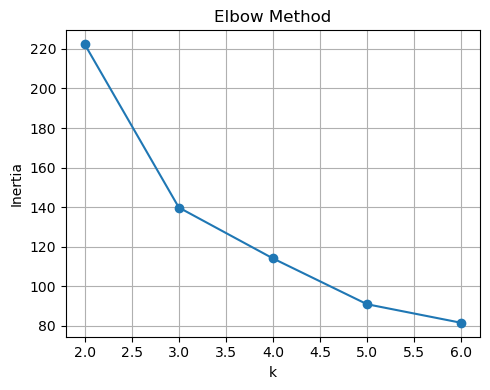

In [6]:
plt.figure(figsize=(5,4))
plt.plot(list(K_range), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.grid(True)

plt.tight_layout()
plt.show()

**Interpretation**

The dataset naturally has three cluster groups, matching the three Iris species.


### 5.2 Silhouette Score

Silhouette score measures how well data points fit in their assigned clusters.

- Highest at k = 2  
- Good at k = 3  
- Decreases for higher k  


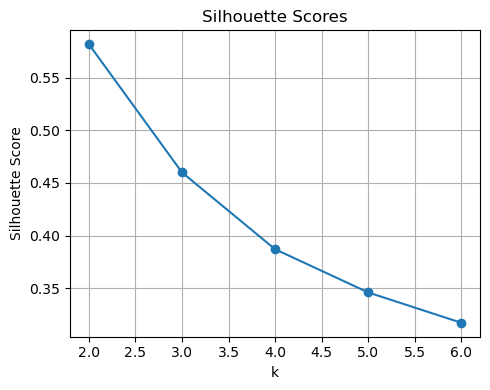

In [7]:
plt.figure(figsize=(5,4))
plt.plot(list(K_range), sil_scores, marker='o')
plt.title('Silhouette Scores')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

**Interpretation**

k = 2 gives clearer separation, but  
k = 3 matches the actual number of species and provides meaningful biological grouping.


---

## 6. KMeans Clustering (k = 3)

KMeans assigns each data point to one of three clusters using only numeric flower traits.  
The model does not see species labels.


In [8]:
k_final = 3
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

print('Model trained successfully!')

Model trained successfully!


---

## 7. Visualization

### 7.1 KMeans Clusters on PCA Plot  
Shows how the model grouped the plants.


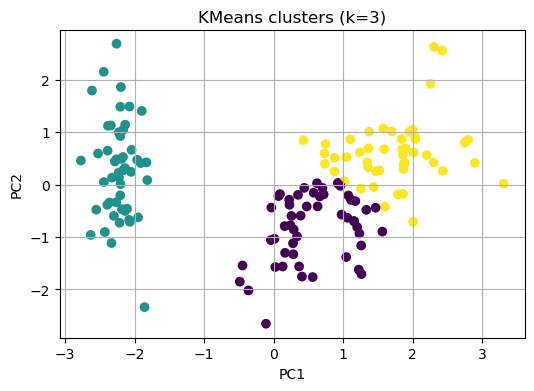

In [9]:
plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title('KMeans clusters (k=3)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

**Interpretation**

- Setosa forms a perfectly separate cluster  
- Versicolor and Virginica overlap  
- This overlap is expected biologically



### 7.2 True Species on PCA Plot  
Shows the actual distribution of species.


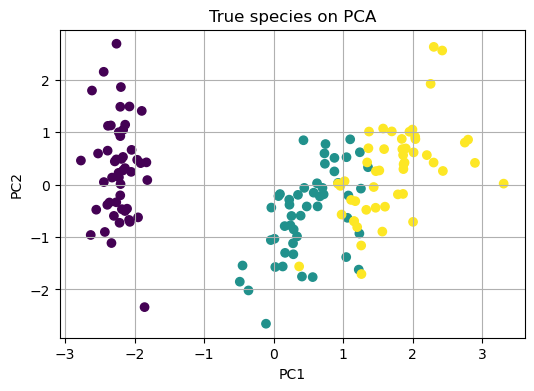

In [10]:
species_to_int = {s:i for i,s in enumerate(np.unique(y_true))}
y_int = np.array([species_to_int[s] for s in y_true])
plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_int)
plt.title('True species on PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

**Interpretation**

- The true species separation matches the shape of the clusters.  
- Confirms that clustering is capturing real structure.


---

## 8. Evaluation Metrics

#### Silhouette Score

In [11]:
sil = silhouette_score(X_scaled, clusters)
print(f"Silhouette: {sil:.4f}")

Silhouette: 0.4599


Indicates moderately good cluster separation.


#### Adjusted Rand Index (ARI)  


In [12]:
ari = adjusted_rand_score(y_true, clusters)
print(f"ARI: {ari:.4f}")

ARI: 0.6201


Shows strong agreement between predicted clusters and true labels.


#### Normalized Mutual Information (NMI)  


In [13]:
nmi = normalized_mutual_info_score(y_true, clusters)
print(f"NMI: {nmi:.4f}")

NMI: 0.6595


Shows good overlap between cluster assignments and species labels.


#### Confusion Matrix  

Shows how each species was assigned to clusters.


In [14]:
cm = confusion_matrix(y_int, clusters)
cm_df = pd.DataFrame(cm, index=np.unique(y_true), columns=[f"cluster_{i}" for i in range(k_final)])
print('Confusion Matrix:')
cm_df

Confusion Matrix:


,cluster_0,cluster_1,cluster_2
setosa,0,50,0
versicolor,39,0,11
virginica,14,0,36


**Interpretation**

- Setosa is perfectly classified  
- Versicolor and Virginica are partially mixed  
- This matches real-world plant similarity patterns  


#### Mapping-Based Accuracy  


In [15]:
mapping = {}
for true_label in np.unique(y_int):
    mask = (y_int == true_label)
    most_common_cluster = np.bincount(clusters[mask]).argmax()
    mapping[most_common_cluster] = true_label
predicted_species = np.array([np.unique(y_true)[mapping[c]] for c in clusters])
accuracy = (predicted_species == y_true).mean()
print("Mapping-based accuracy:", accuracy)

Mapping-based accuracy: 0.8333333333333334


Clustering correctly identifies species 83% of the time without using labels.


---

## 9. Saving Results

A final CSV file (`iris_pca_clusters.csv`) is created with:

- PCA components  
- Cluster numbers  
- Predicted species  
- True species  

Useful for reporting and future analysis.

In [16]:
out_df = pd.DataFrame({
    "pc1": X_pca[:,0], 
    "pc2": X_pca[:,1], 
    "cluster": clusters, 
    "predicted_species": predicted_species, 
    "true_species": y_true
})
out_df.to_csv("iris_pca_clusters.csv", index=False)

print('Saved: iris_pca_clusters.csv with PCA components, clusters, and species labels.')

Saved: iris_pca_clusters.csv with PCA components, clusters, and species labels.


---

## 10. Results and Insights

This section summarizes the key outcomes of the clustering process and interprets what the results mean in the context of plant species separation.

### 10.1 PCA Findings
- PCA reduced the original 4-dimensional data into **2 principal components**.
- These two components retained **~96% of the total variance**, meaning almost all important information was preserved.
- PC1 captured most of the variation (~73%), primarily influenced by **petal length and petal width**.
- The PCA plot visually separated **Setosa clearly**, while **Versicolor and Virginica overlapped**, reflecting their natural similarity.

**Insight:**  
PCA is highly effective for visualizing biological plant traits and understanding how species differ based on morphology.


### 10.2 Optimal Number of Clusters
- The **Elbow method** showed a clear bend at **k = 3**, suggesting three natural clusters.
- The **Silhouette score** was highest at **k = 2**, but still strong at **k = 3**.
- Since the true dataset contains **three species**, selecting **k = 3** aligns with biological reality.

**Insight:**  
While k = 2 provides slightly better numerical separation, **k = 3 reveals the true structure** of the Iris dataset and is the most meaningful choice.



### 10.3 KMeans Clustering Behavior
- KMeans successfully formed **three clusters** based on standardized features.
- Cluster 2 fully captured **Iris Setosa**, which is the most distinct in morphology.
- Versicolor and Virginica were mixed across two clusters due to overlapping characteristics.

**Insight:**  
Clustering naturally reveals that Setosa is unique, while Versicolor and Virginica share similar feature ranges, making them harder to separate.


### 10.4 Evaluation Metrics
- **Silhouette Score:** ~0.46 → indicates moderately well-separated clusters.
- **Adjusted Rand Index (ARI):** ~0.62 → shows strong similarity to true labels.
- **NMI:** ~0.66 → good overlap between predicted clusters and actual species.
- **Mapping Accuracy:** ~83% → unsupervised clustering correctly matches species in most cases.

**Insight:**  
Even without labels, KMeans achieves high alignment with actual species, proving its effectiveness in pattern discovery.


### 10.5 Biological Interpretation
- Setosa is uniquely clustered because it has short petals and small variance across all features.
- Versicolor and Virginica overlap due to similar petal measurements.
- PCA and clustering reflect the true biology of Iris flowers.

**Insight:**  
Machine learning models capture genuine biological structure, confirming that plant traits strongly define species boundaries.


### 10.6 Overall Conclusion
- PCA + KMeans is a powerful combination for discovering patterns in plant species data.
- The model uncovers clear structure without any label usage.
- The Iris dataset remains a benchmark example of how unsupervised learning can reveal meaningful biological grouping.

**Final Takeaway:**  
Clustering with PCA effectively separates plant species and provides strong insights into the natural structure of the Iris dataset.

---

## 11. References

1. Fisher, R. A. (1936). *The Use of Multiple Measurements in Taxonomic Problems*. Annals of Eugenics, 7(2), 179–188.  
   - Original publication introducing the Iris dataset.

2. Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825–2830.  
   - Documentation for the scikit-learn library used for PCA and KMeans.

3. Jolliffe, I. T., & Cadima, J. (2016). *Principal Component Analysis: A Review and Recent Developments*. Philosophical Transactions of the Royal Society A, 374(2065).  
   - Reference for PCA theory and applications.

4. Hartigan, J. A., & Wong, M. A. (1979). *Algorithm AS 136: A K-Means Clustering Algorithm*. Journal of the Royal Statistical Society, Series C.  
   - Classic reference describing the KMeans algorithm.

5. Matplotlib Developers. (2023). *Matplotlib: Visualization with Python*.  
   https://matplotlib.org  
   - Plotting library documentation.

6. Scikit-learn Developers. (2023). *sklearn Documentation*.  
   https://scikit-learn.org/stable/  
   - Official documentation for clustering, metrics, and preprocessing.

7. UCI Machine Learning Repository. *Iris Data Set*.  
   https://archive.ics.uci.edu/ml/datasets/iris  
   - Original dataset source maintained by UCI.

---

